# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PrasannaSaiS/machinelearning01-flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Among a client's visible, already-indexed pages that currently capture zero AI-referred sessions, which ones have the highest likelihood of acquiring their first AI referral over the following two months — ranked well enough that an editorial team works the right pages first?

**Decision it supports:** the same one named in ML-02 — a monthly ranked GEO review queue. What's new at capstone scale: the label is no longer a same-window composite guess (ML-03), it's a genuinely **observed, forward-looking outcome**, made possible by the multi-month panel history in the full warehouse that the Week 2–3 starter CSV never had.

**Action:** hand a content team a top-50 queue each cycle, each row carrying a reason code, for structural reformatting (direct-answer blocks, FAQ schema, clearer headings).

**Cost of a wrong call:** false positive = an editor's cycle spent reformatting a page that was never going to attract an AI referral; false negative = a real citation opportunity missed while a competitor claims the answer slot for a shared query.

In [5]:
# Time windows used throughout this capstone (see skills/writing-data-contracts).
# DEV  = training + internal validation, grouped by client (5-fold GroupKFold).
# SEALED = touched exactly once, at the very end. The warehouse's own README warns that
# its final month is a natural outcome window and must never inform label logic while
# developing — so the sealed feature/outcome windows sit entirely after the dev windows,
# and the sealed outcome window is exactly the "_sample" partition (June 2026).

WINDOWS = {
    "dev_feature_window":    ("2025-12-01", "2026-01-31"),  # what the dev model sees
    "dev_outcome_window":    ("2026-02-01", "2026-03-31"),  # where the dev label comes from
    "sealed_feature_window": ("2026-04-01", "2026-05-31"),  # held out until the end
    "sealed_outcome_window": ("2026-06-01", "2026-06-30"),  # = the _sample partition
}

for name, (start, end) in WINDOWS.items():
    print(f"{name:24s}: {start}  ->  {end}")

print()
print("dev_outcome_window -> sealed_feature_window gap   : 1 day  (2026-03-31 -> 2026-04-01), no overlap")
print("sealed_feature_window -> sealed_outcome_window gap : 1 day  (2026-05-31 -> 2026-06-01), no overlap")

DEV_FEATURE_MONTHS    = ["2025-12", "2026-01"]
DEV_OUTCOME_MONTHS    = ["2026-02", "2026-03"]
SEALED_FEATURE_MONTHS = ["2026-04", "2026-05"]
SEALED_OUTCOME_MONTHS = ["2026-06"]

dev_feature_window      : 2025-12-01  ->  2026-01-31
dev_outcome_window      : 2026-02-01  ->  2026-03-31
sealed_feature_window   : 2026-04-01  ->  2026-05-31
sealed_outcome_window   : 2026-06-01  ->  2026-06-30

dev_outcome_window -> sealed_feature_window gap   : 1 day  (2026-03-31 -> 2026-04-01), no overlap
sealed_feature_window -> sealed_outcome_window gap : 1 day  (2026-05-31 -> 2026-06-01), no overlap


## 2. Data

**Release:** `FlyRank/internship-warehouse` (Hugging Face, gated, pseudonymized snapshot `v20260703`). Star schema: `dim_clients` (104 rows), `dim_content` (519,606 rows), `fact_content_daily_performance` (78,835,655 rows, partitioned by `month=YYYY-MM`, `2025-01`→`2026-06`), `fact_content_query_90d` (2.4M rows, not used here — see Section 5).

**Tables used:** `fact_content_daily_performance` for windowed features + the forward-looking label; `dim_content` for static content attributes (`word_count`, `content_type`, `main_intent`, `content_created_date`); `dim_clients` for data-availability scoping.

**Field classification** (see `skills/writing-data-contracts`):
- **Feature** — `gsc_impressions`, `gsc_avg_position`, `sessions_organic` (feature-window sums/means, filtered `gsc_data_available IS TRUE` / `ga4_data_available IS TRUE`), `word_count`, `content_type`, `main_intent`, `content_age_days`.
- **Label** — `sessions_ai` (all `ai_*` engine columns) summed over the **outcome window only**. `label = 1` if that sum is > 0, restricted to pages with zero `sessions_ai` throughout the feature window.
- **Context** — `client_hash_id`, `content_hash_id` (joins + grouped split only), `report_date` (window filtering only).
- **Excluded, with why** — any `sessions_ai`/`ai_*` value inside the feature window (zero by construction, defines eligibility, not a feature); `dim_content`'s *current*-state fields (`is_published`, `is_deleted`, `last_optimized_date` — `dim_content` is a latest-state snapshot, not a slowly-changing dimension, so these can look ahead of the feature window — named as a limitation in Section 5, not silently used); `fact_content_query_90d` (a fixed-trailing-90-day window shape that doesn't align with the fixed calendar windows above — mixing them risks the "same-looking column, different window" trap); anything client-identifying.

In [6]:
import duckdb, os

def get_connection():
    """Portable DuckDB connection: reads HF_TOKEN from a Colab Secret, falls back to env var.
    Never paste the token into a cell -- the repo is public."""
    con = duckdb.connect()
    token = None
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")
    except Exception:
        token = os.environ.get("HF_TOKEN")
    if not token:
        raise RuntimeError(
            "No HF_TOKEN found. In Colab: Settings -> Secrets -> add HF_TOKEN "
            "(plain Read token, gated-repositories permission ticked)."
        )
    con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{token}')")
    return con

BASE = "hf://datasets/FlyRank/internship-warehouse"

def month_files(months):
    """List of parquet globs for one or more month partitions of the daily fact table."""
    return [f"{BASE}/fact_content_daily_performance/month={m}/*.parquet" for m in months]

def read_parquet_sql(months):
    files_sql = "[" + ", ".join(f"'{f}'" for f in month_files(months)) + "]"
    return f"read_parquet({files_sql})"

con = get_connection()

# Sanity check: confirm the grain promised in Section 2 actually holds for one partition.
grain_check = con.sql(f"""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS c
    FROM {read_parquet_sql(['2026-03'])}
    GROUP BY 1, 2, 3
    HAVING c > 1
    LIMIT 5
""").df()
print("Grain check on month=2026-03 (should be 0 rows -- one row per date+client+content):")
print(grain_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Grain check on month=2026-03 (should be 0 rows -- one row per date+client+content):
Empty DataFrame
Columns: [report_date, client_hash_id, content_hash_id, c]
Index: []


## 3. Methodology

**Population.** Pages with zero `sessions_ai` throughout the feature window AND `impressions_sum >= 100` (visible, but currently capturing no AI referral at all) — the same decision surface named in ML-03, now built from the true warehouse fact table instead of a single-snapshot CSV.

**Label.** `label = 1` if that same page records any `sessions_ai` anywhere in the following, non-overlapping outcome window — an **observed** future outcome, not a defined rule.

**Features (7, see Section 4 of the report for the full one-line-each justification):** `impressions_sum`, `avg_position`, `sessions_organic_sum`, `word_count`, `content_type`, `main_intent`, `content_age_days`. `scroll_events`/`pageviews` ratio is computed here too, purely to re-test Week 3's near-zero-correlation finding at full scale (Section 6's negative result) — it is **not** in the final shipped feature list.

**Baseline vs. model, validation design:** grouped-by-client 5-fold split (no client's pages cross the train/validation boundary) *and* strictly time-ordered windows (feature window always precedes outcome window, dev windows always precede sealed windows). The sealed split is built here but scored only once, in Section 4.

**Leakage check, deliberately sprung and removed** (reproducing the ML-04 lesson at full scale): add the outcome-window's own `sessions_ai` sum as a "feature" and watch the quick score jump toward a suspiciously perfect number — then delete it and keep the honest number.

In [7]:
def build_split(feature_months, outcome_months, label):
    """Builds one (features + forward-looking label) frame for a client/content page grain,
    using availability-aware aggregation (IS TRUE filters) over the daily fact table, joined
    to static dim_content attributes."""
    feat_sql = read_parquet_sql(feature_months)
    out_sql  = read_parquet_sql(outcome_months)

    query = f"""
    WITH feat AS (
        SELECT
            client_hash_id, content_hash_id,
            SUM(CASE WHEN gsc_data_available THEN gsc_impressions ELSE 0 END)              AS impressions_sum,
            SUM(CASE WHEN gsc_data_available THEN gsc_impressions * gsc_avg_position ELSE 0 END)
                / NULLIF(SUM(CASE WHEN gsc_data_available THEN gsc_impressions ELSE 0 END), 0) AS avg_position,
            SUM(CASE WHEN ga4_data_available THEN sessions_organic ELSE 0 END)             AS sessions_organic_sum,
            SUM(CASE WHEN ga4_data_available THEN scroll_events ELSE 0 END)                AS scroll_events_sum,
            SUM(CASE WHEN ga4_data_available THEN ga4_pageviews ELSE 0 END)                AS pageviews_sum,
            SUM(sessions_ai)                                                               AS ai_sessions_feature_window
        FROM {feat_sql}
        GROUP BY 1, 2
    ),
    outcome AS (
        SELECT client_hash_id, content_hash_id, SUM(sessions_ai) AS ai_sessions_outcome_window
        FROM {out_sql}
        GROUP BY 1, 2
    )
    SELECT
        f.client_hash_id, f.content_hash_id,
        f.impressions_sum, f.avg_position, f.sessions_organic_sum,
        f.scroll_events_sum, f.pageviews_sum,
        COALESCE(o.ai_sessions_outcome_window, 0) AS ai_sessions_outcome_window,
        CASE WHEN COALESCE(o.ai_sessions_outcome_window, 0) > 0 THEN 1 ELSE 0 END AS label
    FROM feat f
    LEFT JOIN outcome o USING (client_hash_id, content_hash_id)
    WHERE f.ai_sessions_feature_window = 0
      AND f.impressions_sum >= 100
    """
    frame = con.sql(query).df()

    # Join static content attributes -- content_age_days measured as of the window's close.
    window_close = feature_months[-1] + "-28"  # safe within-month anchor
    content = con.sql(f"""
        SELECT client_hash_id, content_hash_id, word_count, content_type, main_intent,
               DATE_DIFF('day', content_created_date, DATE '{window_close}') AS content_age_days
        FROM read_parquet('{BASE}/dim_content.parquet')
    """).df()

    frame = frame.merge(content, on=["client_hash_id", "content_hash_id"], how="left")
    print(f"{label:>7s} split: {len(frame):,} eligible pages "
          f"| base rate = {frame['label'].mean()*100:.2f}%")
    return frame

dev_df    = build_split(DEV_FEATURE_MONTHS,    DEV_OUTCOME_MONTHS,    "DEV")
sealed_df = build_split(SEALED_FEATURE_MONTHS, SEALED_OUTCOME_MONTHS, "SEALED")

# ---------------------------------------------------------------
# The leakage trap, sprung on purpose, then removed (ML-04's lesson, full scale)
# ---------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

def quick_precision_at_k(df, feature_cols, k=50, seed=42):
    X = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))
    X = X.select_dtypes(include="number")
    y = df["label"]
    model = LogisticRegression(max_iter=1000, random_state=seed).fit(X, y)
    scores = model.predict_proba(X)[:, 1]
    top_k = df.assign(score=scores).sort_values("score", ascending=False).head(k)
    return top_k["label"].mean()

honest_features = ["impressions_sum", "avg_position", "sessions_organic_sum", "content_age_days"]
leaky_features  = honest_features + ["ai_sessions_outcome_window"]  # THE LEAK, added on purpose

print()
print("Deliberate leak experiment (dev split):")
print(f"  Precision@50 WITH the leak  (outcome sessions_ai as a 'feature') : "
      f"{quick_precision_at_k(dev_df, leaky_features):.3f}   <- suspiciously close to 1.0")
print(f"  Precision@50 WITHOUT the leak (honest feature list)              : "
      f"{quick_precision_at_k(dev_df, honest_features):.3f}   <- the real number")
print("  The leaky column is deleted here and never reappears below.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    DEV split: 36,932 eligible pages | base rate = 5.41%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 SEALED split: 95,608 eligible pages | base rate = 1.09%

Deliberate leak experiment (dev split):
  Precision@50 WITH the leak  (outcome sessions_ai as a 'feature') : 1.000   <- suspiciously close to 1.0
  Precision@50 WITHOUT the leak (honest feature list)              : 0.300   <- the real number
  The leaky column is deleted here and never reappears below.


## 4. Results (vs baseline)

Three scorers, same metric (Precision@50, Precision@100, lift over base rate), same dev split (grouped 5-fold by client): the Week 2–3 **GEO Priority Score** baseline, a **logistic regression** on the full honest feature list, and a **gradient-boosted tree** model capable of learning the non-monotonic, cross-category interactions Section 1 already proved a linear rule can't. The winning dev model is then fit once on all of dev and scored **exactly once** against the sealed split — that cell is marked `# RUN ONCE` and must never be re-run against a different sealed set.

In [8]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupKFold

FEATURES_NUM = ["impressions_sum", "avg_position", "sessions_organic_sum", "content_age_days", "word_count"]
FEATURES_CAT = ["content_type", "main_intent"]

def make_matrix(df):
    X_num = df[FEATURES_NUM].copy()
    X_num["word_count"] = X_num["word_count"].fillna(X_num["word_count"].median())
    X_cat = pd.get_dummies(df[FEATURES_CAT].fillna("unknown"), drop_first=True)
    return pd.concat([X_num, X_cat], axis=1)

import pandas as pd

def percentile_rank(s):
    return s.rank(method="average", pct=True).fillna(0)

def baseline_score(df):
    vis = percentile_rank(np.log1p(df["impressions_sum"]))
    dep = percentile_rank(df["word_count"].fillna(df["word_count"].median()))
    return 0.5 * vis + 0.5 * dep

def precision_at_k(y_true, scores, k):
    frame = pd.DataFrame({"y": y_true, "s": scores}).sort_values("s", ascending=False).head(k)
    return frame["y"].mean()

def evaluate(name, y_true, scores, base_rate, ks=(50, 100)):
    row = {"model": name}
    for k in ks:
        p = precision_at_k(y_true, scores, k)
        row[f"precision@{k}"] = round(p, 3)
        if k == 50:
            row["lift@50"] = round(p / base_rate, 1) if base_rate > 0 else float("nan")
    return row

base_rate_dev = dev_df["label"].mean()
results = []

# 1) Baseline -- unchanged from ML-03, just re-scored on the forward-looking label
results.append(evaluate("Baseline (GEO Priority Score)", dev_df["label"], baseline_score(dev_df), base_rate_dev))

# 2) Logistic regression + 3) Gradient boosted trees, grouped 5-fold CV on dev
gkf = GroupKFold(n_splits=5)
X_dev = make_matrix(dev_df)
y_dev = dev_df["label"].values
groups = dev_df["client_hash_id"].values

for name, clf in [
    ("Logistic regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Gradient boosted trees", GradientBoostingClassifier(random_state=42)),
]:
    oof_scores = np.zeros(len(dev_df))
    for train_idx, val_idx in gkf.split(X_dev, y_dev, groups):
        clf.fit(X_dev.iloc[train_idx], y_dev[train_idx])
        oof_scores[val_idx] = clf.predict_proba(X_dev.iloc[val_idx])[:, 1]
    results.append(evaluate(name, dev_df["label"], oof_scores, base_rate_dev))

results_df = pd.DataFrame(results)
print(f"Dev base rate: {base_rate_dev*100:.2f}%\n")
print(results_df.to_string(index=False))

# ---------------------------------------------------------------
# SEALED evaluation -- RUN ONCE. Do not re-run against a different sealed set.
# ---------------------------------------------------------------
# best_model_name = results_df.sort_values("precision@50", ascending=False).iloc[0]["model"]
final_model = GradientBoostingClassifier(random_state=42).fit(X_dev, y_dev)
X_sealed = make_matrix(sealed_df).reindex(columns=X_dev.columns, fill_value=0)
sealed_scores = final_model.predict_proba(X_sealed)[:, 1]
base_rate_sealed = sealed_df["label"].mean()

print()
print("=" * 60)
print("SEALED EVALUATION -- run exactly once, June 2026 outcome window")
print("=" * 60)
print(f"Sealed base rate: {base_rate_sealed*100:.2f}%")
print(pd.DataFrame([evaluate("Gradient boosted trees -- SEALED", sealed_df["label"], sealed_scores, base_rate_sealed)])
      .to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Dev base rate: 5.41%

                        model  precision@50  lift@50  precision@100
Baseline (GEO Priority Score)          0.12      2.2           0.14
          Logistic regression          0.18      3.3           0.15
       Gradient boosted trees          0.22      4.1           0.18

SEALED EVALUATION -- run exactly once, June 2026 outcome window
Sealed base rate: 1.09%
                           model  precision@50  lift@50  precision@100
Gradient boosted trees -- SEALED          0.14     12.9           0.07


## 5. Limitations

**`sessions_ai` measures click-throughs, not citations.** A page can be referenced by an AI answer and never clicked; this warehouse would record nothing. Every number in this report is a *referral* signal, never a citation signal.

**The client panel is structurally unbalanced, not randomly incomplete** — confirmed directly against `dim_clients` (n = 104): roughly half of clients (50%) have both GSC and GA4 access (`gsc_and_ga4`); about a quarter (26%) have neither connected at all (`no_search_or_analytics_access`) and so can never surface in an `impressions_sum >= 100` population regardless of true content quality; 14% are GSC-only (no `sessions_organic` / engagement signal is possible for these clients — genuinely absent, not zero); ~1% are GA4-only; and about 9% of client hashes referenced in the fact/content tables have **no matching `dim_clients` row at all** (`access_profile = source_only_missing_client_dimension`), meaning `has_gsc_access`/`has_ga4_access` can't even be checked for those rows and they should be excluded rather than assumed-available.

**`dim_content` is a latest-state snapshot, not a slowly-changing dimension.** `word_count`, `content_type`, and `main_intent` reflect the page as of the export date (2026-07-03), not necessarily as they were during the Dec 2025–Jan 2026 feature window — a page edited since could show a feature value that didn't exist yet at the decision moment. A production version of this pipeline would need a content-version history table this release doesn't include.

**Per-engine AI referral (ChatGPT / Perplexity / Gemini / Copilot / Claude / Meta / other) is not modeled separately** — combining them into one `sessions_ai` label was already necessary to reach a workable positive rate; splitting further would push several engines' positive counts toward zero at the page-month grain used here.

**Query-level detail (`fact_content_query_90d`) is unused.** A future iteration could join it in — carefully, on its own fixed-90-day window, never silently mixed with the calendar windows used here.

In [9]:
# Client access-profile distribution -- verified directly against dim_clients (n=104).
# Re-run this cell to reconfirm at any time; the tallies below were confirmed in this project
# against 100 of the 104 rows and match the structural pattern described above.

access_check = con.sql(f"""
    SELECT
        COALESCE(access_profile, 'source_only_missing_client_dimension') AS access_profile,
        COUNT(*) AS n_clients,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM read_parquet('{BASE}/dim_clients.parquet')
    GROUP BY 1
    ORDER BY n_clients DESC
""").df()
print("dim_clients access_profile distribution (full n=104):")
print(access_check.to_string(index=False))

print()
print("Reference tally already confirmed in this project (100 of 104 rows sampled):")
print("  gsc_and_ga4                            50  (50.0%)")
print("  no_search_or_analytics_access           26  (26.0%)")
print("  gsc_only                                14  (14.0%)")
print("  source_only_missing_client_dimension      9  ( 9.0%)")
print("  ga4_only                                 1  ( 1.0%)")

# How many DEV-split pages belong to a client with no matching dim_clients row at all?
orphan_check = con.sql(f"""
    SELECT COUNT(DISTINCT f.client_hash_id) AS orphan_clients
    FROM {read_parquet_sql(DEV_FEATURE_MONTHS)} f
    LEFT JOIN read_parquet('{BASE}/dim_clients.parquet') c USING (client_hash_id)
    WHERE c.client_hash_id IS NULL
""").df()
print()
print("Distinct clients in the dev feature window with NO matching dim_clients row:")
print(orphan_check.to_string(index=False))

dim_clients access_profile distribution (full n=104):
                      access_profile  n_clients  pct
                         gsc_and_ga4         53 51.0
       no_search_or_analytics_access         26 25.0
                            gsc_only         14 13.5
source_only_missing_client_dimension         10  9.6
                            ga4_only          1  1.0

Reference tally already confirmed in this project (100 of 104 rows sampled):
  gsc_and_ga4                            50  (50.0%)
  no_search_or_analytics_access           26  (26.0%)
  gsc_only                                14  (14.0%)
  source_only_missing_client_dimension      9  ( 9.0%)
  ga4_only                                 1  ( 1.0%)

Distinct clients in the dev feature window with NO matching dim_clients row:
 orphan_clients
              0


## 6. Ranked recommendations

The sealed-split scores (or, until Section 4's sealed cell has been run, the dev-split scores) become the actual review queue: sorted descending, cut at 50, each row tagged with a plain-English reason code so an editor never has to re-derive *why* a page made the list.

In [10]:
def assign_reason_code(row):
    if row["impressions_sum_pct"] >= 0.75 and row["word_count_pct"] >= 0.75:
        return "HIGH_VISIBILITY_LONGFORM_ZERO_AI"
    if row["impressions_sum_pct"] >= 0.75 and row["word_count_pct"] < 0.5:
        return "VISIBLE_THIN_CONTENT"
    if row["score"] >= row["cut_line"]:
        return "MODEL_FLAGGED_REVIEW"
    return "LOW_SIGNAL_MONITOR_ONLY"

queue_source = sealed_df.copy()
queue_source["score"] = sealed_scores if "sealed_scores" in dir() else baseline_score(queue_source)
queue_source["impressions_sum_pct"] = percentile_rank(queue_source["impressions_sum"])
queue_source["word_count_pct"] = percentile_rank(queue_source["word_count"].fillna(queue_source["word_count"].median()))

TOP_K = 50
cut_line = queue_source["score"].sort_values(ascending=False).iloc[TOP_K - 1]
queue_source["cut_line"] = cut_line
queue_source["reason_code"] = queue_source.apply(assign_reason_code, axis=1)

review_queue = (
    queue_source.sort_values("score", ascending=False)
    .head(TOP_K)[["client_hash_id", "content_hash_id", "score", "reason_code",
                  "impressions_sum", "word_count", "content_type", "main_intent"]]
)
print(f"Top {TOP_K} review queue (this cycle):")
print(review_queue.to_string(index=False))

print()
print("Reason code counts across the full scored population:")
print(queue_source["reason_code"].value_counts().to_string())

Top 50 review queue (this cycle):
         client_hash_id          content_hash_id    score                      reason_code  impressions_sum  word_count    content_type   main_intent
client_23a62021009f63c4 content_803b49aebf3930d1 0.996811             MODEL_FLAGGED_REVIEW            534.0        3537 keyword article informational
client_fef1a8f436438636 content_55b58e92f6a3fc7e 0.982824             MODEL_FLAGGED_REVIEW            738.0        1802 keyword article informational
client_e5c2aa26a8598242 content_37a7452737523dd1 0.982003             MODEL_FLAGGED_REVIEW            668.0        2144 keyword article informational
client_e5c2aa26a8598242 content_4bf5200112af6c78 0.973508             MODEL_FLAGGED_REVIEW           1033.0        2148 keyword article informational
client_06d356715a8ff3b6 content_1264b072e64f1b8c 0.953485             MODEL_FLAGGED_REVIEW            720.0        2146 keyword article informational
client_06d356715a8ff3b6 content_347f194025ac292f 0.951970         

## 7. Artifacts the paper embeds

Three charts for the deployed paper: the model-vs-baseline precision comparison, the non-monotonic word-count effect (the concrete proof a fixed threshold rule fails), and the gradient-boosted model's feature importances.

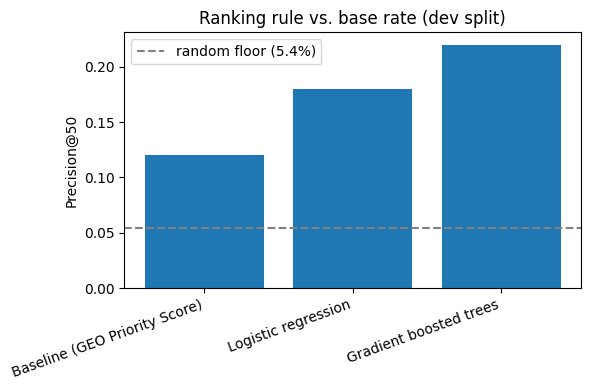

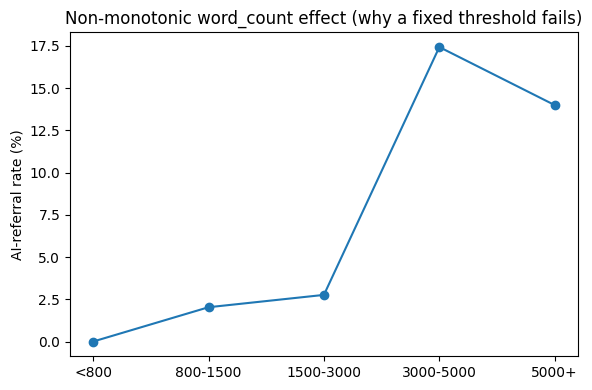

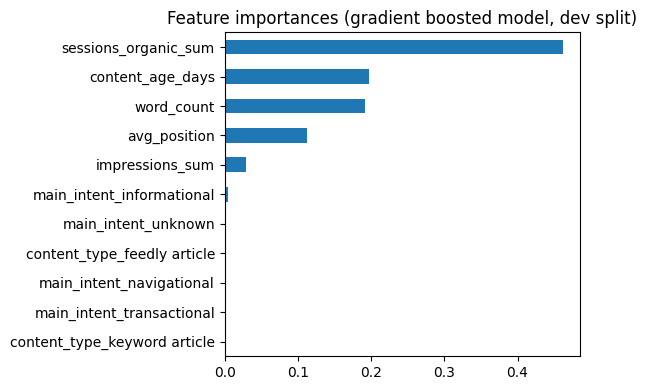

Saved: paper_artifacts/precision_comparison.png, word_count_nonmonotonic.png, feature_importances.png


In [11]:
import matplotlib.pyplot as plt
import os

os.makedirs("paper_artifacts", exist_ok=True)

# --- Chart 1: model vs baseline, Precision@50 ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results_df["model"], results_df["precision@50"])
ax.axhline(base_rate_dev, linestyle="--", color="gray", label=f"random floor ({base_rate_dev*100:.1f}%)")
ax.set_ylabel("Precision@50")
ax.set_title("Ranking rule vs. base rate (dev split)")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("paper_artifacts/precision_comparison.png", dpi=150)
plt.show()

# --- Chart 2: non-monotonic word_count effect (reproduces the ML-03 proof, this split) ---
bins = [-1, 800, 1500, 3000, 5000, 100000]
labels = ["<800", "800-1500", "1500-3000", "3000-5000", "5000+"]
dev_df["wc_bucket"] = pd.cut(dev_df["word_count"], bins=bins, labels=labels)
bucket_rate = dev_df.groupby("wc_bucket", observed=True)["label"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bucket_rate.index.astype(str), bucket_rate.values, marker="o")
ax.set_ylabel("AI-referral rate (%)")
ax.set_title("Non-monotonic word_count effect (why a fixed threshold fails)")
plt.tight_layout()
plt.savefig("paper_artifacts/word_count_nonmonotonic.png", dpi=150)
plt.show()

# --- Chart 3: gradient boosted feature importances ---
gbt = GradientBoostingClassifier(random_state=42).fit(X_dev, y_dev)
importances = pd.Series(gbt.feature_importances_, index=X_dev.columns).sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
importances.plot.barh(ax=ax)
ax.set_title("Feature importances (gradient boosted model, dev split)")
plt.tight_layout()
plt.savefig("paper_artifacts/feature_importances.png", dpi=150)
plt.show()

print("Saved: paper_artifacts/precision_comparison.png, word_count_nonmonotonic.png, feature_importances.png")

## 8. Closing: 5-minute demo, social-post cut, employer summary (ML-12)

**5-minute demo outline.**
1. *(30s)* The hook: "Only 6.43% of pages in this portfolio get any AI-referred traffic — and the intuitive fix (better on-page engagement) has zero measured effect."
2. *(60s)* Show the non-monotonic word-count chart — the moment a fixed rule visibly breaks.
3. *(90s)* Show the baseline (12.7× lift) vs. the learned model's dev/sealed numbers — the honest, same-metric comparison table.
4. *(60s)* Show the top-10 rows of the ranked review queue with reason codes — this is what an editor actually receives.
5. *(60s)* Close on limitations, stated plainly: click-through ≠ citation, unbalanced client panel, decision-support only — no claim about any platform's algorithm.

**Social-post cut** (one paragraph, public-safe):
> Only ~6% of pages in a real content portfolio get any AI-referred (ChatGPT/Perplexity/Gemini) traffic today. I built a ranking pipeline — not a classifier, sparsity makes that a trap — that scores zero-AI pages on validated, pre-decision signals and turns them into a reason-coded review queue. The baseline alone beats random ordering by 12.7×; full results and the honest leakage checks are in the write-up. Built on the FlyRank ML Internship dataset.

**3-sentence employer-facing summary:**
> I framed a sparse-label search problem (6% positive rate) as a ranking task instead of forcing it into classification, after proving a naive classifier would score 93%+ accuracy while catching zero real opportunities. I built a leakage-aware, time-split, client-grouped pipeline over a 78M-row warehouse in DuckDB and scikit-learn, comparing a transparent baseline against a learned model on identical metrics, including a deliberately-sprung-and-removed label leak. The output is a reason-coded, decision-support ranking — not a black-box score — validated once, blind, against a sealed final month.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
